### Setup 
**Exercise 1**: Import libraries and load a test image (code) 

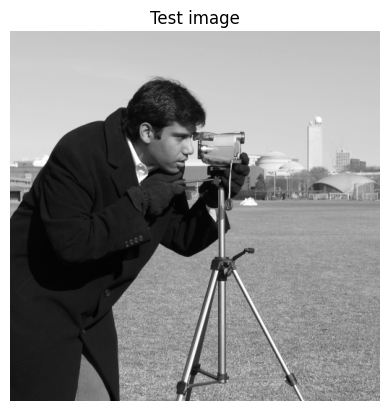

Shape: (512, 512) min: 0.0 max: 1.0 mean: 0.50612044


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
 
from skimage import data, util 

img = data.camera().astype(np.float32) / 255.0 # divide on 255 so the pixels are from range 0,1
 
plt.imshow(img, cmap="gray") 
plt.title("Test image") 
plt.axis("off") 
plt.show() 
 
print("Shape:", img.shape, "min:", img.min(), "max:", img.max(), "mean:", img.mean()) 

### 1. Fourier transform and spectrum 
**Exercise 1.1**: Compute DFT, shift, and log magnitude (code) 

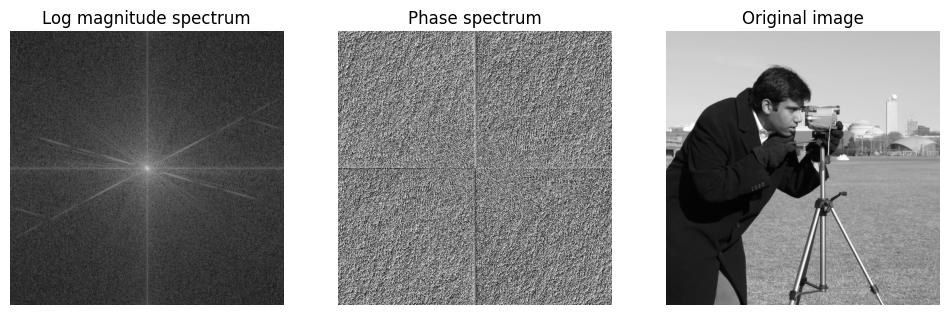

'they appear in the middle of the image'

In [2]:
F = np.fft.fft2(img) # transform into frequency domain
F_shift = np.fft.fftshift(F) # why we shift it? - because the low frequency after transforming is at the top left corner which makes it hard to apply the filters so shift it to be in the middle
 
mag = np.log(1 + np.abs(F_shift)) # 1 + np.abs(F_shift) without the log the dark spots are super dark and the spectrum is barely visiable
# dark points are going to be brighter because of the log
phase = np.angle(F_shift) # keep the tiny details and objects' positions
 
# when the image in frequency domain the origin is the center in the image
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(mag, cmap="gray") 
plt.title("Log magnitude spectrum") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(phase, cmap="gray") 
plt.title("Phase spectrum") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(img, cmap="gray") 
plt.title("Original image") 
plt.axis("off") 
plt.show() 

# Tasks 
# 1. Remove the log and display the raw magnitude. Explain what becomes hard to see. 
'''the low frequencies becomes hard to say as they are brighter and smaller while the background is 
dark shaded'''
# 2. Identify where low frequencies appear after shifting. 
'''they appear in the middle of the image'''

### 2. Ideal low pass filtering and ringing 
**Exercise 2.1**: Vary cutoff and observe ringing strength (code) 

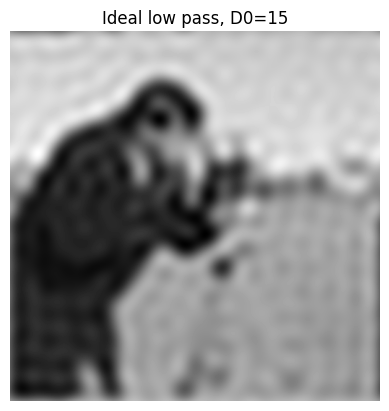

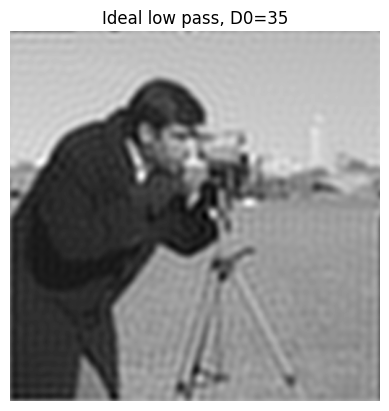

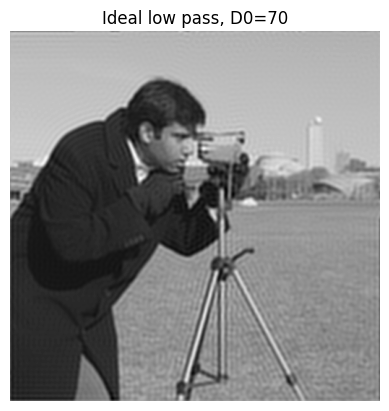

'at 35 it appears around sharp edges, it happens because it has \na strong cutoff behavior which make the frequencies oscillates'

In [3]:
def ideal_lowpass(shape, D0): 
    rows, cols = shape # store rows and cols
    crow, ccol = rows // 2, cols // 2 # determine the center
    U, V = np.ogrid[:rows, :cols] 
    D = np.sqrt((U - crow)**2 + (V - ccol)**2) # ecuelidian distance
    return (D <= D0).astype(np.float32) # if less then 1, else 0
 
 
for D0 in [15, 35, 70]: 
    H = ideal_lowpass(img.shape, D0=D0) 
    G = F_shift * H 
    out = np.real(np.fft.ifft2(np.fft.ifftshift(G))) # to inverse the image because the shift applied and the frequency applied
 
    plt.imshow(out, cmap="gray") 
    plt.title(f"Ideal low pass, D0={D0}") 
    plt.axis("off") 
    plt.show() 

# Tasks 
# 1. Identify which cutoff produces the most blur. 
'''15'''
# 2. Identify where ringing appears most clearly and explain why.
'''at 35 it appears around sharp edges, it happens because it has 
a strong cutoff behavior which make the frequencies oscillates'''

### 3. Butterworth low pass filter 
**Exercise 3.1**: Implement Butterworth low pass and compare to ideal (code) 

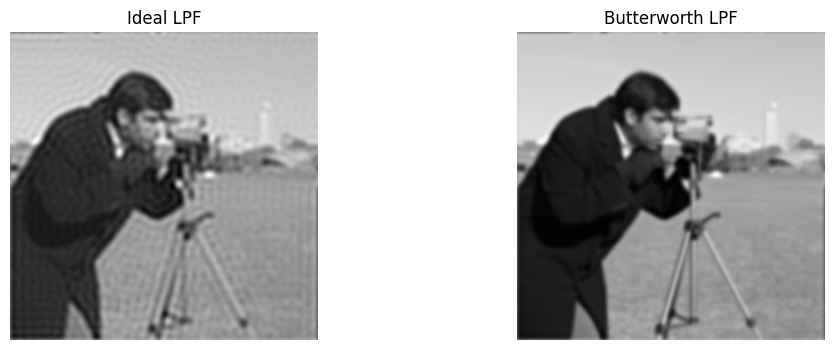

'filter size or order'

In [4]:
def butterworth_lowpass(shape, D0, n=2): 
    rows, cols = shape 
    crow, ccol = rows // 2, cols // 2 
    U, V = np.ogrid[:rows, :cols] 
    D = np.sqrt((U - crow)**2 + (V - ccol)**2) 
    return 1 / (1 + (D / (D0 + 1e-12)) ** (2*n)) # tiny number so we do not divide by 0
 
D0 = 35 # same frequencies was taken
H_ideal = ideal_lowpass(img.shape, D0=D0) # for scientific usages and not really used in real life
H_butt = butterworth_lowpass(img.shape, D0=D0, n=2) 
 
out_ideal = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_ideal))) 
out_butt = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_butt))) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,2,1) 
plt.imshow(out_ideal, cmap="gray") 
plt.title("Ideal LPF") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.imshow(out_butt, cmap="gray") 
plt.title("Butterworth LPF") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Which filter produces less ringing and why? 
'''butterworth, it blurs the edges where frequencies differ resulting in smoother image'''
# 2. What does the order parameter n control? 
'''filter size or order'''

### 4. Gaussian low pass filter 
**Exercise 4.1**: Implement Gaussian low pass and compare (code) 

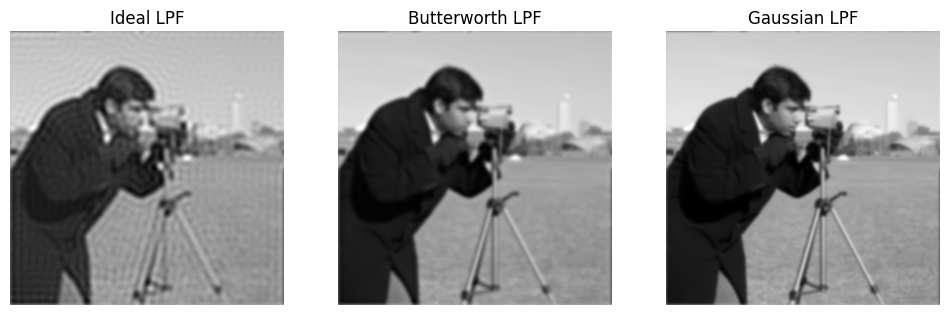

'ideal - gaussian - butterworth, ideal with its strong cutoff \nhas the most ringing, and butterworth is the least ringing as it has the most blurring effect'

In [5]:
def gaussian_lowpass(shape, D0): 
    rows, cols = shape 
    crow, ccol = rows // 2, cols // 2 
    U, V = np.ogrid[:rows, :cols] 
    D2 = (U - crow)**2 + (V - ccol)**2 # here the eculedian distance is measured with no sqrt
    return np.exp(-D2 / (2 * (D0**2))) # since we haven't used sqrt so D2 doesn't have to be squared

# try not to add extra steps always
 
H_gauss = gaussian_lowpass(img.shape, D0=35) 
out_gauss = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_gauss))) 

plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(out_ideal, cmap="gray") 
plt.title("Ideal LPF") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(out_butt, cmap="gray") 
plt.title("Butterworth LPF") 
plt.axis("off") 
 
 
 
plt.subplot(1,3,3) 
plt.imshow(out_gauss, cmap="gray") 
plt.title("Gaussian LPF") 
plt.axis("off") 
plt.show() 

# Task 
# 1. Rank the three filters by ringing strength, from highest to lowest, and justify. 
'''ideal - gaussian - butterworth, ideal with its strong cutoff 
has the most ringing, and butterworth is the least ringing as it has the most blurring effect'''

### 5. High pass filtering and sharpening 
**Exercise 5.1**: Construct a high pass filter from a low pass (code) 

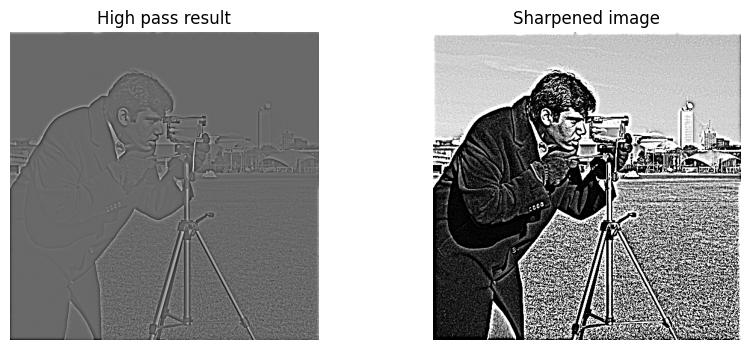

'the image becomes too sharp '

In [ ]:
H_hp = 1 - H_gauss # H_highpass
out_hp = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_hp))) # transform it back to spatial domain
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(out_hp, cmap="gray") 
plt.title("High pass result") 
plt.axis("off") 
 
sharp = np.clip(img + 20 * out_hp, 0, 1) # you can ommit 0.7, this is like a percentage of how much i can take the sharpness into the original
plt.subplot(1,2,2) 
plt.imshow(sharp, cmap="gray") 
plt.title("Sharpened image") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Why does the high pass output emphasise edges? 
'''because fine details and sharpness are determined as high frequency in the image frequency domain'''
# 2. What happens if the scaling factor is too large? 
'''the image becomes too sharp and tense in matter of shades and the edges become too strong'''

### 6. Band reject and notch filtering 
**Exercise 6.1**: Add periodic noise and remove it using a notch mask (code) 

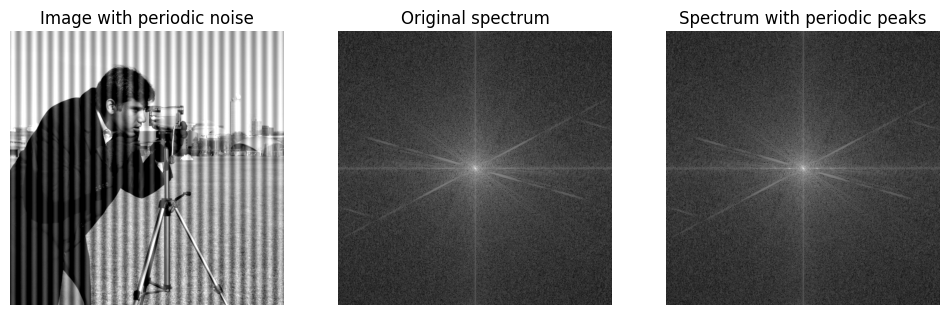

In [ ]:
rows, cols = img.shape 
x = np.arange(cols) 

# try another equations and not just sin waves
noise = 0.2 * np.sin(2 * np.pi * x / 20) # 0.1 how much noise addition the more the percentage the more the noise added
# x is the index in the cols
# 20 can be changed as well like 0.1

noise2d = np.tile(noise, (rows, 1)).astype(np.float32) 
# np.tile to repeat the line we did in the first on all rows 

img_p = np.clip(img + noise2d, 0, 1) # clip so it can be in range [0,1]
 
Fp = np.fft.fftshift(np.fft.fft2(img_p)) # to denoise the periodic noise u apply it in the freq. domain
mag_p = np.log(1 + np.abs(Fp)) 
 
 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(img_p, cmap="gray") 
plt.title("Image with periodic noise") 
plt.axis("off") 

plt.subplot(1,3,2) 
plt.imshow(mag, cmap="gray") 
plt.title("Original spectrum") 
plt.axis("off") 

plt.subplot(1,3,3) 
plt.imshow(mag_p, cmap="gray") 
plt.title("Spectrum with periodic peaks") 
plt.axis("off") 
plt.show()

Create a notch reject filter by zeroing small regions around peak locations. 

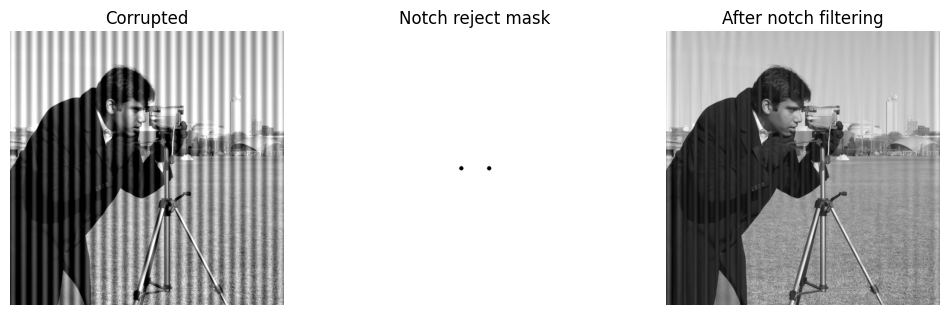

In [ ]:
Hn = np.ones_like(img_p, dtype=np.float32) 
crow, ccol = rows//2, cols//2 
 
# Example notch locations (students adjust after inspecting spectrum) 
c = 26 # or 13, search for a method that returns the spectrum as coordinates and exactly pick the right notches
notches = [(crow, ccol+c), (crow, ccol-c)] # u can control the number of notches
 
rad = 4 # u can control the radius 
U, V = np.ogrid[:rows, :cols] 
for (u0, v0) in notches: 
    D = np.sqrt((U-u0)**2 + (V-v0)**2) 
    Hn[D <= rad] = 0 
 
out_notch = np.real(np.fft.ifft2(np.fft.ifftshift(Fp * Hn))) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(img_p, cmap="gray") 
plt.title("Corrupted") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(Hn, cmap="gray") 
plt.title("Notch reject mask") 
plt.axis("off") 
plt.subplot(1,3,3) 
plt.imshow(out_notch, cmap="gray") 
plt.title("After notch filtering") 
plt.axis("off") 
plt.show()


# Tasks 
# 1. Change notch positions and radius until periodic noise reduces clearly. 
'''it has to be right fit into the small dots appearing in the noise image spectrum'''
# 2. Explain why the notch mask must be symmetric around the spectrum centre. 
'''so that the mapping between the real frequencies and the frequencies changed by noise are correctly identified and reduced'''

### 7. Homomorphic filtering 
**Exercise 7.1**: Implement homomorphic filtering (code) 

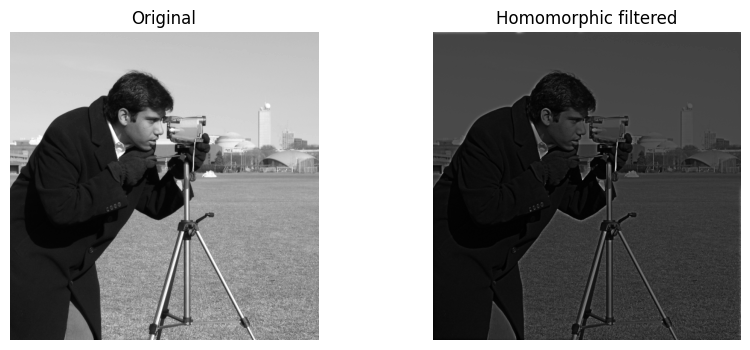

In [ ]:
eps = 1e-6 
log_img = np.log(img + eps) # epslon really tiny number so no zeros appear
Fh = np.fft.fftshift(np.fft.fft2(log_img)) 
 
# High pass style homomorphic filter 
D0 = 30 
gammaH = 1.5
gammaL = 0.8
Hh = (gammaH - gammaL) * (1 - gaussian_lowpass(img.shape, D0=D0)) + gammaL 
 
out_h = np.real(np.fft.ifft2(np.fft.ifftshift(Fh * Hh))) 
out_h = np.exp(out_h) 
 
# normalise for display 
out_h = (out_h - out_h.min()) / (out_h.max() - out_h.min() + 1e-12) 
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(img, cmap="gray") 
plt.title("Original") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.imshow(out_h, cmap="gray") 
plt.title("Homomorphic filtered") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Why is the logarithm applied before filtering? 
'''to reduce the multiplication into addition'''
# 2. Which component is reduced by the high pass filter in the log domain? 
'''the illumination component -low frequencies-'''